# SisFall

In [1]:
import numpy as np 
import pandas as pd 
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/nurulaminchoudhury/sisfall-adl/Sisfall_ADL.csv")
df

,0,1,2,3,4,5,6,7,8,activity
0,17,-179,-99,-18,-504,-352,76,-697,-279,Walking slowly
1,15,-174,-90,-53,-568,-306,48,-675,-254,Walking slowly
2,1,-176,-81,-84,-613,-271,-2,-668,-221,Walking slowly
3,-10,-180,-77,-104,-647,-227,-34,-697,-175,Walking slowly
4,-21,-191,-63,-128,-675,-191,-74,-741,-133,Walking slowly
...,...,...,...,...,...,...,...,...,...,...
3879098,250,-11,-58,-7,86,-5,994,-14,-277,"Lateral fall while sitting, caused by fainting..."
3879099,255,-13,-65,-8,87,-5,994,-17,-279,"Lateral fall while sitting, caused by fainting..."
3879100,251,-15,-61,-8,89,-3,997,-17,-281,"Lateral fall while sitting, caused by fainting..."
3879101,254,-14,-60,-6,90,-2,997,-13,-281,"Lateral fall while sitting, caused by fainting..."


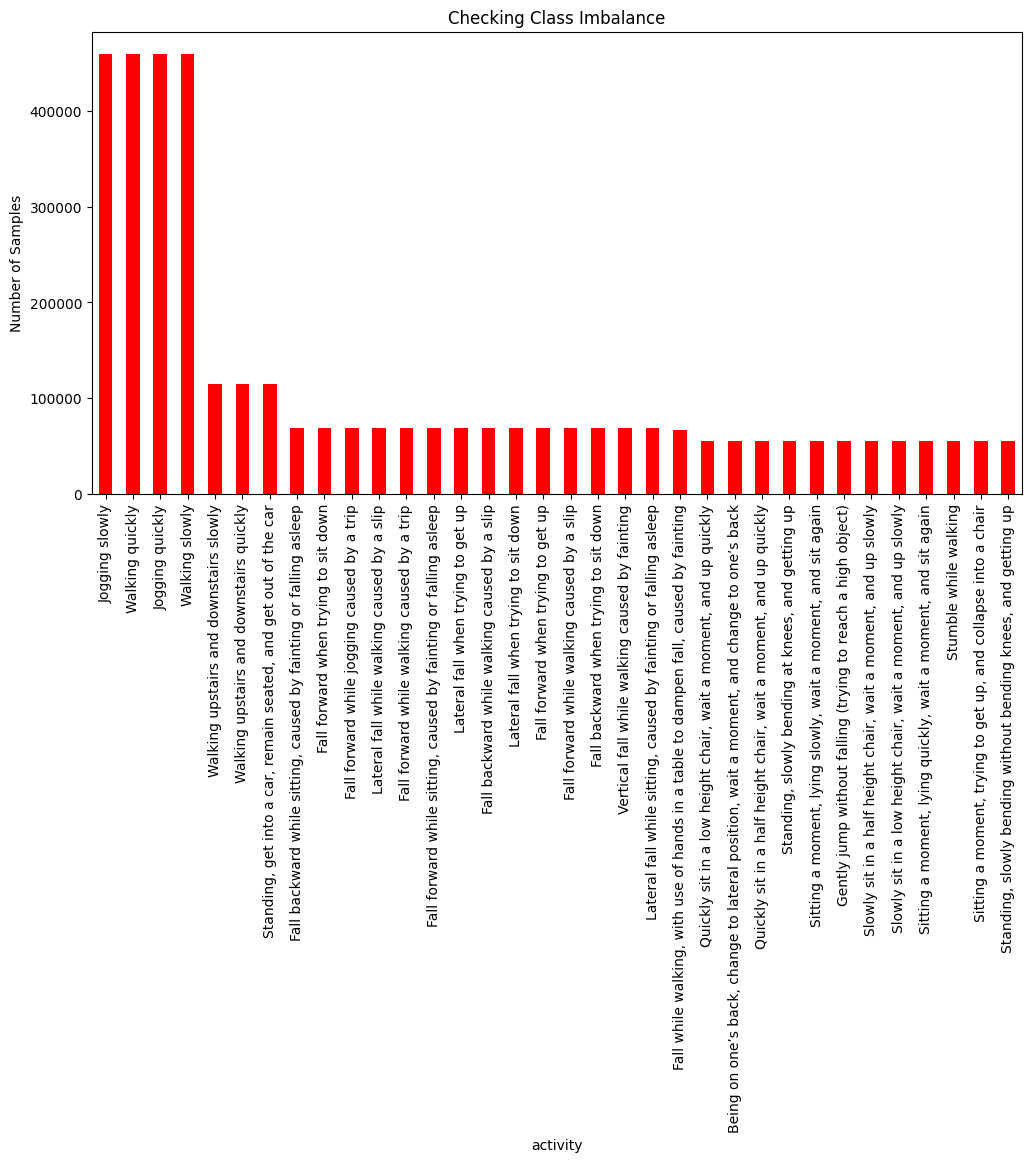

In [2]:

df.activity.unique()

plt.figure(figsize=(12,6))
df['activity'].value_counts().plot(kind='bar',title='Checking Class Imbalance',color='red')
plt.xlabel('activity')
plt.ylabel('Number of Samples')
plt.show()


In [3]:
fall_activities = [
    "Fall forward while walking caused by a slip",
    "Fall backward while walking caused by a slip",
    "Lateral fall while walking caused by a slip",
    "Fall forward while walking caused by a trip",
    "Fall forward while jogging caused by a trip",
    "Vertical fall while walking caused by fainting",
    "Fall while walking, with use of hands in a table to dampen fall, caused by fainting",
    "Fall forward when trying to get up",
    "Lateral fall when trying to get up",
    "Fall forward when trying to sit down",
    "Fall backward when trying to sit down",
    "Lateral fall when trying to sit down",
    "Fall forward while sitting, caused by fainting or falling asleep",
    "Fall backward while sitting, caused by fainting or falling asleep",
    "Lateral fall while sitting, caused by fainting or falling asleep",
]

df['Fall_Class'] = df['activity'].apply(lambda x: 'Fall' if x in fall_activities else 'Non-Fall')

# Verify every unique activity string got matched as intended
check = df.groupby('activity')['Fall_Class'].first()
print(check.to_string())

activity
Being on one’s back, change to lateral position, wait a moment, and change to one’s back    Non-Fall
Fall backward when trying to sit down                                                           Fall
Fall backward while sitting, caused by fainting or falling asleep                               Fall
Fall backward while walking caused by a slip                                                    Fall
Fall forward when trying to get up                                                              Fall
Fall forward when trying to sit down                                                            Fall
Fall forward while jogging caused by a trip                                                     Fall
Fall forward while sitting, caused by fainting or falling asleep                                Fall
Fall forward while walking caused by a slip                                                     Fall
Fall forward while walking caused by a trip                                       

In [4]:

from sklearn.preprocessing import LabelEncoder

df = df[df['Fall_Class'].notna()].copy()

le = LabelEncoder()
df['Fall_Class_Encoded'] = le.fit_transform(df['Fall_Class'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("✅ Cleaned Label Mapping (Original → Encoded):")
for k, v in label_mapping.items():
    print(f"{k} → {v}")


df
df1 = df.drop(['activity'], axis=1)
df1.head()

print(df.columns.tolist())
print(type(df.columns[0]))

✅ Cleaned Label Mapping (Original → Encoded):
Fall → 0
Non-Fall → 1
['0', '1', '2', '3', '4', '5', '6', '7', '8', 'activity', 'Fall_Class', 'Fall_Class_Encoded']
<class 'str'>


In [5]:

from scipy import stats

# Step 2: Segmentation function -------------------------------------------------
def create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded'):
    feature_columns = [str(i) for i in range(9)]  
    segments = []
    labels = []
    for i in range(0, len(df) - time_steps, step):
        segment = []
        for col in feature_columns:
            segment.append(df[col].values[i : i + time_steps])
        segment = np.array(segment)
        segments.append(segment)
        label = stats.mode(df[label_col].iloc[i : i + time_steps], keepdims=True)[0][0]
        labels.append(label)
    X = np.asarray(segments, dtype=np.float32).transpose(0, 2, 1)
    y = np.asarray(labels)
    return X, y

# Step 3: Apply segmentation -------------------------------------------------
X, y = create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded')

# Step 4: Verify output -------------------------------------------------
print("Segmented Data Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Unique Labels:", np.unique(y))
print("Sample Labels:", y[:10])

Segmented Data Shape: (387901, 100, 9)
Labels Shape: (387901,)
Unique Labels: [0 1]
Sample Labels: [1 1 1 1 1 1 1 1 1 1]


In [6]:

from sklearn.model_selection import train_test_split

# Step 1: Stratified Train-Test Split
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Step 2: Print dataset shapes
print("Training Data Shape:", X_train_res.shape, "| Labels:", y_train_res.shape)
print("Testing Data Shape :", X_test_res.shape,  "| Labels:", y_test_res.shape)

print(df['Fall_Class'].value_counts())

Training Data Shape: (310320, 100, 9) | Labels: (310320,)
Testing Data Shape : (77581, 100, 9) | Labels: (77581,)
Fall_Class
Non-Fall    2847267
Fall        1031836
Name: count, dtype: int64


In [7]:
#For Tetsing
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf


# ======================================================
# Noise Estimation Module
# ======================================================

def noise_estimation_module(inputs):

    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu',
        name='noise_conv1'
    )(inputs)

    x = layers.BatchNormalization(
        name='noise_bn'
    )(x)

    noise = layers.Conv1D(
        filters=1,
        kernel_size=3,
        padding='same',
        activation='softplus',
        name='noise_map'          # IMPORTANT
    )(x)

    return noise


# ======================================================
# Noise-aware Gating
# ======================================================

def noise_aware_gating(features, noise, name):

    weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name=name+"_weight"
    )(noise)

    gated = layers.Multiply(
        name=name+"_gated"
    )([features, weight])

    return gated


# ======================================================
# Noise-aware Transformer Encoder
# ======================================================

def noise_aware_transformer_encoder(
    inputs,
    noise,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.01
):

    attn = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
        name='transformer_attention'
    )(inputs, inputs)

    noise_weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name='transformer_noise_weight'
    )(noise)

    attn = layers.Multiply(
        name='transformer_noise_gating'
    )([attn, noise_weight])

    x = layers.Add(
        name='transformer_residual1'
    )([attn, inputs])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_ln1'
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            ff_dim,
            activation='relu',
            name='ffn_dense1'
        ),
        layers.Dense(
            inputs.shape[-1],
            name='ffn_dense2'
        )
    ],
    name="transformer_ffn")

    x_ffn = ffn(x)

    x_ffn = layers.Multiply(
        name='transformer_ffn_gating'
    )([x_ffn, noise_weight])

    x = layers.Add(
        name='transformer_residual2'
    )([x_ffn, x])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_output'
    )(x)

    return x


# ======================================================
# CNN Block
# ======================================================

def noise_aware_cnn_block(inputs,
                          noise,
                          filters,
                          kernel_size,
                          block_name):

    x = layers.Conv1D(
        filters,
        kernel_size,
        padding='same',
        activation='relu',
        name=block_name+"_conv"
    )(inputs)

    x = layers.BatchNormalization(
        name=block_name+"_bn"
    )(x)

    x = noise_aware_gating(
        x,
        noise,
        block_name
    )

    return x


# ======================================================
# NA-MSCT-Net
# ======================================================

def build_na_msct_net(
    input_shape=(100,9),
    num_classes=4
):

    inputs = keras.Input(
        shape=input_shape,
        name="sensor_input"
    )

    ##################################################

    noise = noise_estimation_module(inputs)

    ##################################################

    global_cnn = noise_aware_cnn_block(
        inputs,
        noise,
        64,
        3,
        "global_cnn"
    )

    ##################################################

    cnn3 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        3,
        "cnn3"
    )

    cnn5 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        5,
        "cnn5"
    )

    cnn7 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        7,
        "cnn7"
    )

    ##################################################

    transformer = noise_aware_transformer_encoder(
        global_cnn,
        noise,
        head_size=32,
        num_heads=2,
        ff_dim=64
    )

    ##################################################

    fusion = layers.Concatenate(
        name="feature_fusion"
    )([cnn3,
       cnn5,
       cnn7,
       transformer])

    ##################################################

    gap = layers.GlobalMaxPooling1D(
        name="global_pool"
    )(fusion)

    ##################################################

    embedding = layers.Dense(
        128,
        activation='relu',
        name="embedding_128"      # IMPORTANT
    )(gap)

    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name="classifier"
    )(embedding)

    ##################################################

    model = keras.Model(
        inputs,
        outputs,
        name="NA-MSCT-Net"
    )

    return model


# ======================================================
# Build Model
# ======================================================

model = build_na_msct_net(
    input_shape=(100,9),
    num_classes=2
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1785397020.945053      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "NA-MSCT-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 100, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_conv1         │ (None, 100, 32)   │        896 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_bn            │ (None, 100, 32)   │        128 │ noise_conv1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_conv     │ (None, 100, 64)   │      1,792 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_map (Conv1D)  │ (None, 100, 1)    │         97 │ noise_bn[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_bn       │ (None, 100, 64)   │        256 │ global_cnn_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_weight   │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_gated    │ (None, 100, 64)   │          0 │ global_cnn_bn[0]… │
│ (Multiply)          │                   │            │ global_cnn_weigh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 100, 64)   │     16,640 │ global_cnn_gated… │
│ (MultiHeadAttentio… │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 64)   │          0 │ transformer_atte… │
│ (Multiply)          │                   │            │ transformer_nois… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_residu… │ (None, 100, 64)   │          0 │ transformer_nois… │
│ (Add)               │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ln1     │ (None, 100, 64)   │        128 │ transformer_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn     │ (None, 100, 64)   │      8,320 │ transformer_ln1[… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn3_conv (Conv1D)  │ (None, 100, 64)   │     12,352 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn5_conv (Conv1D)  │ (None, 100, 64)   │     20,544 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn7_conv (Conv1D)  │ (None, 100, 64)   │     28,736 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_ga… │ (None, 100, 64)   │          0 │ transformer_ffn[… │
│ (Multiply)          │                   │            │ transformer_nois

 Total params: 123,939 (484.14 KB)

 Trainable params: 123,363 (481.89 KB)

 Non-trainable params: 576 (2.25 KB)

In [8]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

def add_noise_snr_batch(X, snr_low=20, snr_high=60):
    X_noisy = np.zeros_like(X)
    for i in range(X.shape[0]):
        signal = X[i]
        snr_db = np.random.uniform(snr_low, snr_high)
        Ps = np.mean(signal ** 2)
        Pn = Ps / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(Pn), signal.shape)
        X_noisy[i] = signal + noise
    return X_noisy

X_train_noisy = add_noise_snr_batch(X_train_res, 20, 60)
X_combined = np.concatenate([X_train_res, X_train_noisy])
y_combined = np.concatenate([y_train_res, y_train_res])

# Cast labels to float32 for binary_crossentropy + sigmoid
y_combined = y_combined.astype('float32')
y_test_res = y_test_res.astype('float32')

# Class weights to counter imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_combined), y=y_combined)
class_weight = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath='best_na_msct_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

history = model.fit(
    X_combined,
    y_combined,
    validation_data=(X_test_res, y_test_res),
    epochs=100,
    batch_size=128,                                                                                                                                                                                     
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Class weights: {0: np.float64(1.879747525532147), 1: np.float64(0.6811925699258485)}
Epoch 1/100
  22/4849 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.6616 - loss: 0.9374   

I0000 00:00:1785397058.806484     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4849/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8629 - loss: 0.3199

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


4849/4849 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - accuracy: 0.8847 - loss: 0.2634 - val_accuracy: 0.9125 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 2/100
4847/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9143 - loss: 0.1945

...

4849/4849 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9966 - loss: 0.0087 - val_accuracy: 0.9953 - val_loss: 0.0217 - learning_rate: 3.1250e-05
Epoch 64/100
4844/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9966 - loss: 0.0088

4849/4849 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9967 - loss: 0.0086 - val_accuracy: 0.9951 - val_loss: 0.0215 - learning_rate: 3.1250e-05
Epoch 65/100
4847/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9968 - loss: 0.0085

4849/4849 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.9969 - loss: 0.0085 - val_accuracy: 0.9950 - val_loss: 0.0215 - learning_rate: 3.1250e-05
Epoch 66/100
4844/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9968 - loss: 0.0088

4849/4849 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.9967 - loss: 0.0085 - val_accuracy: 0.9951 - val_loss: 0.0222 - learning_rate: 3.1250e-05
Epoch 67/100
4848/4849 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9969 - loss: 0.0079

4849/4849 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.9969 - loss: 0.0082 - val_accuracy: 0.9953 - val_loss: 0.0218 - learning_rate: 3.1250e-05


In [9]:
results = model.evaluate(X_test_res, y_test_res, verbose=0)
metric_names = model.metrics_names  

for name, value in zip(metric_names, results):
    print(f"Test {name}: {value:.4f}")

test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(X_test_res, y_test_res, verbose=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test AUC      : {test_auc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test loss: 0.0207
Test compile_metrics: 0.9948


ValueError: not enough values to unpack (expected 5, got 2)

In [12]:
results = model.evaluate(X_test_res, y_test_res, verbose=1)

print("\n========== Test Performance ==========")
print(f"Test Loss      : {results[0]:.4f}")
print(f"Test Accuracy  : {results[1]*100:.2f}%")


2425/2425 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9948 - loss: 0.0207

========== Test Performance ==========
Test Loss      : 0.0207
Test Accuracy  : 99.48%


In [13]:
import numpy as np

# Prediction probabilities
y_prob = model.predict(X_test_res)

# Convert probabilities to binary labels
y_pred = (y_prob > 0.5).astype(int).flatten()

# True labels
y_true = y_test_res.astype(int)

2425/2425 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [15]:
import numpy as np

# Predict probabilities
y_prob = model.predict(X_test_res, verbose=1)

print("Prediction Shape :", y_prob.shape)
print("True Label Shape :", y_test_res.shape)

# ---------------------------------------------------
# Handle both Sigmoid (1 output) and Softmax (2 outputs)
# ---------------------------------------------------

if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    # Softmax output
    y_pred = np.argmax(y_prob, axis=1)
    y_score = y_prob[:, 1]      # Probability of positive (Fall) class

elif y_prob.ndim == 2 and y_prob.shape[1] == 1:
    # Sigmoid output
    y_score = y_prob.ravel()
    y_pred = (y_score >= 0.5).astype(int)

else:
    # Already 1-D output
    y_score = y_prob.ravel()
    y_pred = (y_score >= 0.5).astype(int)

# Flatten true labels
y_true = np.array(y_test_res).ravel().astype(int)

print("Prediction Labels :", y_pred.shape)
print("Ground Truth      :", y_true.shape)

2425/2425 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Prediction Shape : (77581, 2)
True Label Shape : (77581,)
Prediction Labels : (77581,)
Ground Truth      : (77581,)


Confusion Matrix

[[20472   164]
 [  237 56708]]


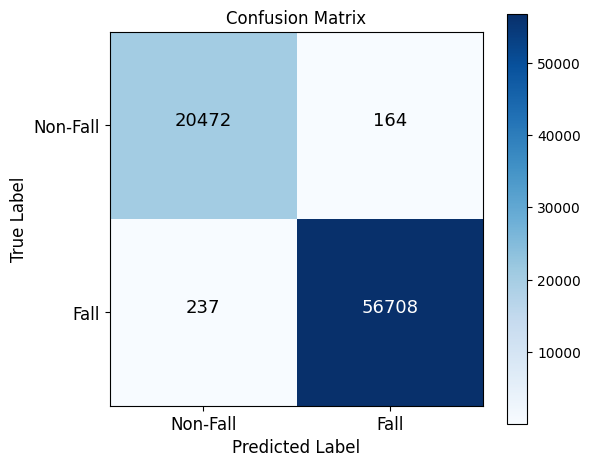

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix\n")
print(cm)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Non-Fall", "Fall"]

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

threshold = cm.max()/2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,
                 i,
                 str(cm[i,j]),
                 ha="center",
                 color="white" if cm[i,j] > threshold else "black",
                 fontsize=13)

plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report

print("\n================ Classification Report ================\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Fall", "Fall"],
    digits=4
))


================ Classification Report ================

              precision    recall  f1-score   support

    Non-Fall     0.9886    0.9921    0.9903     20636
        Fall     0.9971    0.9958    0.9965     56945

    accuracy                         0.9948     77581
   macro avg     0.9928    0.9939    0.9934     77581
weighted avg     0.9948    0.9948    0.9948     77581



In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

print("\n================ Overall Performance ================\n")

print(f"Accuracy           : {accuracy_score(y_true,y_pred)*100:.2f}%")
print(f"Precision          : {precision_score(y_true,y_pred):.4f}")
print(f"Recall             : {recall_score(y_true,y_pred):.4f}")
print(f"F1-score           : {f1_score(y_true,y_pred):.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy_score(y_true,y_pred):.4f}")
print(f"MCC                : {matthews_corrcoef(y_true,y_pred):.4f}")
print(f"Cohen's Kappa      : {cohen_kappa_score(y_true,y_pred):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_true,y_score):.4f}")


================ Overall Performance ================

Accuracy           : 99.48%
Precision          : 0.9971
Recall             : 0.9958
F1-score           : 0.9965
Balanced Accuracy  : 0.9939
MCC                : 0.9868
Cohen's Kappa      : 0.9868
ROC-AUC            : 0.9995


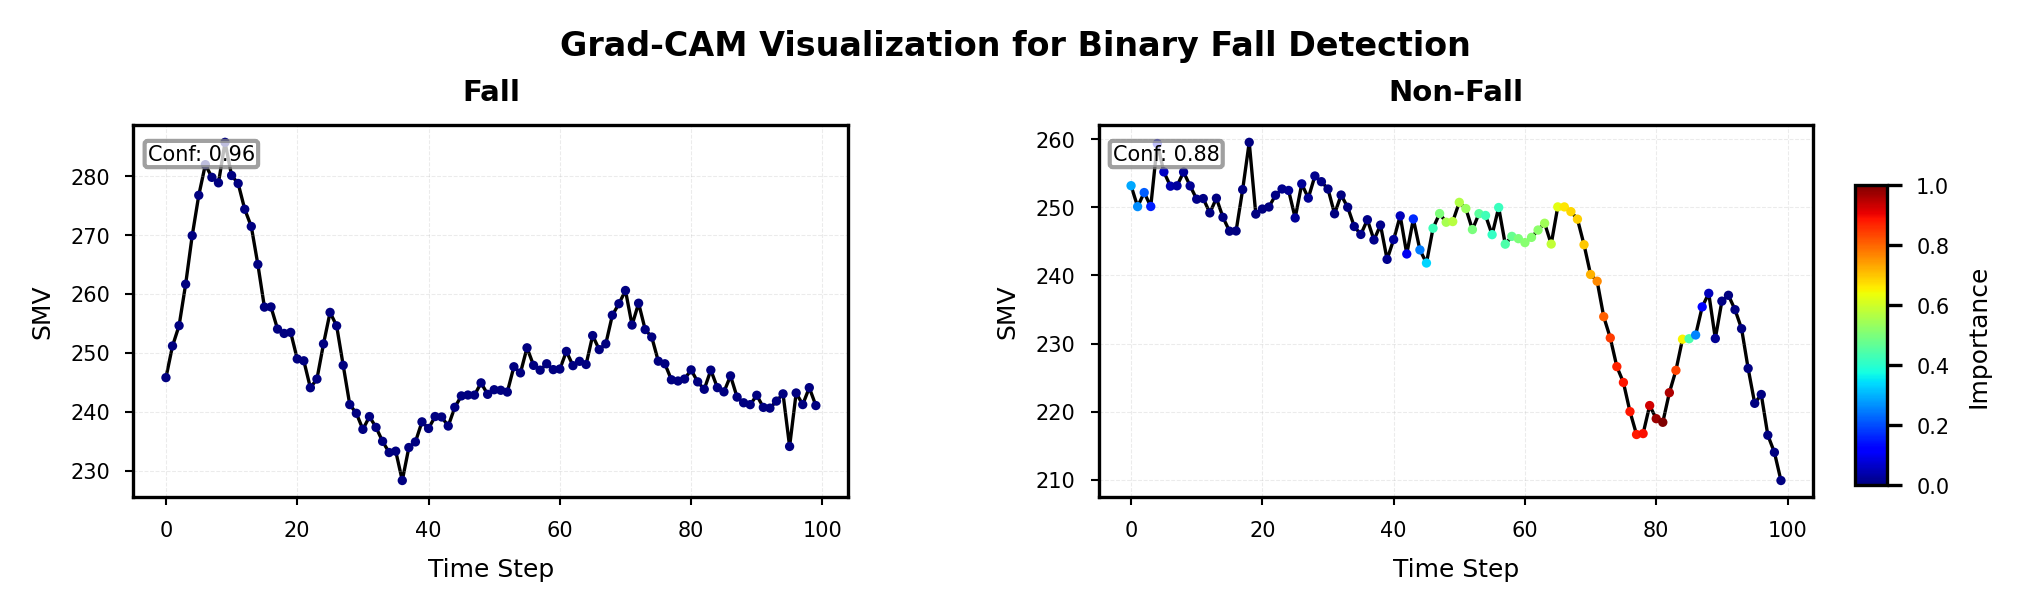

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# Grad-CAM Function
# ============================================================

def gradcam_1d(model, sample, layer_name="cnn7_gated"):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(sample)

        pred_class = tf.argmax(predictions[0])

        loss = predictions[:, pred_class]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(
        grads,
        axis=1
    )

    conv_outputs = conv_outputs[0]

    weights = weights[0]

    cam = tf.reduce_sum(
        conv_outputs * weights,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = gaussian_filter1d(
        cam,
        sigma=2
    )

    cam = cam / (cam.max() + 1e-8)

    confidence = np.max(predictions.numpy())

    return cam, int(pred_class.numpy()), confidence


# ============================================================
# Binary Class Names
# ============================================================

class_names = [
    "Fall",
    "Non-Fall"
]

# ============================================================
# IEEE Plot Settings
# ============================================================

plt.rcParams.update({

    "font.size":6,
    "axes.titlesize":7,
    "axes.labelsize":6,
    "xtick.labelsize":5,
    "ytick.labelsize":5,
    "legend.fontsize":5

})

# ============================================================
# Figure (1×2)
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(7,2),

    dpi=300,

    sharex=False,

    sharey=False

)

vmin = 0
vmax = 1

# ============================================================
# Loop over binary classes
# ============================================================

for cls in range(2):

    idxs = np.where(y_test_res == cls)[0]

    sample_idx = None

    # Find one correctly classified sample

    for idx in idxs:

        pred = np.argmax(

            model.predict(
                X_test_res[idx:idx+1],
                verbose=0
            )

        )

        if pred == cls:

            sample_idx = idx
            break

    if sample_idx is None:

        sample_idx = idxs[0]

    x = X_test_res[sample_idx:sample_idx+1]

    cam, pred, conf = gradcam_1d(

        model,
        x,
        layer_name="cnn7_gated"

    )

    # =====================================================
    # Signal Magnitude Vector (SMV)
    # =====================================================

    signal = np.sqrt(

        X_test_res[sample_idx,:,0]**2 +

        X_test_res[sample_idx,:,1]**2 +

        X_test_res[sample_idx,:,2]**2

    )

    ax = axes[cls]

    # =====================================================
    # Plot
    # =====================================================

    ax.plot(

        signal,

        color='black',

        linewidth=0.8,

        zorder=1

    )

    scatter = ax.scatter(

        np.arange(len(signal)),

        signal,

        c=cam,

        cmap='jet',

        s=5,

        edgecolors='none',

        vmin=vmin,

        vmax=vmax,

        zorder=2

    )

    # =====================================================

    ax.set_title(

        class_names[cls],

        fontsize=7,

        fontweight='bold'

    )

    ax.text(

        0.02,

        0.95,

        f"Conf: {conf:.2f}",

        transform=ax.transAxes,

        fontsize=5,

        va='top',

        bbox=dict(

            facecolor='white',

            edgecolor='gray',

            alpha=0.75,

            boxstyle='round,pad=0.15'

        )

    )

    ax.set_xlabel(

        "Time Step",

        fontsize=6

    )

    ax.set_ylabel(

        "SMV",

        fontsize=6

    )

    ax.tick_params(

        axis='both',

        labelsize=5,

        width=0.5,

        length=2

    )

    ax.grid(

        linestyle='--',

        linewidth=0.25,

        alpha=0.25

    )

# ============================================================
# Layout
# ============================================================

plt.subplots_adjust(

    left=0.08,

    right=0.88,

    bottom=0.20,

    top=0.82,

    wspace=0.35

)

# ============================================================
# Colorbar
# ============================================================

cax = fig.add_axes([0.90,0.22,0.015,0.50])

cbar = fig.colorbar(

    scatter,

    cax=cax

)

cbar.set_label(

    "Importance",

    fontsize=6

)

cbar.ax.tick_params(

    labelsize=5

)

# ============================================================
# Title
# ============================================================

fig.suptitle(

    "Grad-CAM Visualization for Binary Fall Detection",

    fontsize=8,

    fontweight='bold'

)

# ============================================================
# Save
# ============================================================

plt.savefig(

    "GradCAM_Binary_FallDetection.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# MobiFall

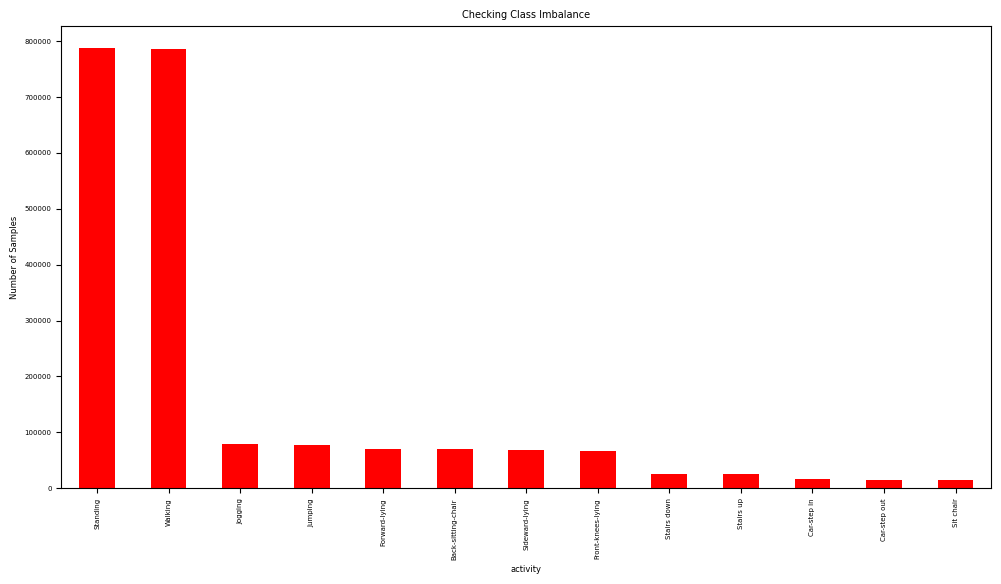

In [20]:
import numpy as np 
import pandas as pd 
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/nurulaminchoudhury/mobiact-fall-adl/Mobiact.csv")
df.activity.unique()

plt.figure(figsize=(12,6))
df['activity'].value_counts().plot(kind='bar',title='Checking Class Imbalance',color='red')
plt.xlabel('activity')
plt.ylabel('Number of Samples')
plt.show()


In [21]:
from sklearn.preprocessing import LabelEncoder

fall_activities = [
    "Forward-lying",
    "Front-knees-lying",
    "Back-sitting-chair",
    "Sideward-lying",
]

df['Fall_Class'] = df['activity'].apply(lambda x: 'Fall' if x in fall_activities else 'Non-Fall')

check = df.groupby('activity')['Fall_Class'].first()
print(check.to_string())

df = df[df['Fall_Class'].notna()].copy()
le = LabelEncoder()
df['Fall_Class_Encoded'] = le.fit_transform(df['Fall_Class'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("✅ Cleaned Label Mapping (Original → Encoded):")
for k, v in label_mapping.items():
    print(f"{k} → {v}")

df
df1 = df.drop(['activity'], axis=1)
df1.head()
print(df.columns.tolist())
print(type(df.columns[0]))

activity
Back-sitting-chair        Fall
Car-step in           Non-Fall
Car-step out          Non-Fall
Forward-lying             Fall
Front-knees-lying         Fall
Jogging               Non-Fall
Jumping               Non-Fall
Sideward-lying            Fall
Sit chair             Non-Fall
Stairs down           Non-Fall
Stairs up             Non-Fall
Standing              Non-Fall
Walking               Non-Fall
✅ Cleaned Label Mapping (Original → Encoded):
Fall → 0
Non-Fall → 1
['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'ori_x', 'ori_y', 'ori_z', 'activity', 'Fall_Class', 'Fall_Class_Encoded']
<class 'str'>


In [22]:

from scipy import stats
from sklearn.model_selection import train_test_split

# Step 2: Segmentation function -------------------------------------------------

def create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded'):
    feature_columns = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'ori_x', 'ori_y', 'ori_z']
    segments = []
    labels = []
    for i in range(0, len(df) - time_steps, step):
        segment = []
        for col in feature_columns:
            segment.append(df[col].values[i : i + time_steps])
        segment = np.array(segment)
        segments.append(segment)
        label = stats.mode(df[label_col].iloc[i : i + time_steps], keepdims=True)[0][0]
        labels.append(label)
    X = np.asarray(segments, dtype=np.float32).transpose(0, 2, 1)
    y = np.asarray(labels)
    return X, y

# Step 3: Apply segmentation -------------------------------------------------
X, y = create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded')

# Step 4: Verify output -------------------------------------------------
print("Segmented Data Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Unique Labels:", np.unique(y))
print("Sample Labels:", y[:10])

# Step 1: Stratified Train-Test Split
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split( X, y,test_size=0.20,stratify=y,random_state=42)

# Step 2: Print dataset shapes
print("Training Data Shape:", X_train_res.shape, "| Labels:", y_train_res.shape)
print("Testing Data Shape :", X_test_res.shape,  "| Labels:", y_test_res.shape)

print(df['Fall_Class'].value_counts())

Segmented Data Shape: (210101, 100, 9)
Labels Shape: (210101,)
Unique Labels: [0 1]
Sample Labels: [0 0 0 0 0 0 0 0 0 0]
Training Data Shape: (168080, 100, 9) | Labels: (168080,)
Testing Data Shape : (42021, 100, 9) | Labels: (42021,)
Fall_Class
Non-Fall    1826314
Fall         274787
Name: count, dtype: int64


In [23]:
#For Tetsing
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf


# ======================================================
# Noise Estimation Module
# ======================================================

def noise_estimation_module(inputs):

    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu',
        name='noise_conv1'
    )(inputs)

    x = layers.BatchNormalization(
        name='noise_bn'
    )(x)

    noise = layers.Conv1D(
        filters=1,
        kernel_size=3,
        padding='same',
        activation='softplus',
        name='noise_map'          # IMPORTANT
    )(x)

    return noise


# ======================================================
# Noise-aware Gating
# ======================================================

def noise_aware_gating(features, noise, name):

    weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name=name+"_weight"
    )(noise)

    gated = layers.Multiply(
        name=name+"_gated"
    )([features, weight])

    return gated


# ======================================================
# Noise-aware Transformer Encoder
# ======================================================

def noise_aware_transformer_encoder(
    inputs,
    noise,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.01
):

    attn = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
        name='transformer_attention'
    )(inputs, inputs)

    noise_weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name='transformer_noise_weight'
    )(noise)

    attn = layers.Multiply(
        name='transformer_noise_gating'
    )([attn, noise_weight])

    x = layers.Add(
        name='transformer_residual1'
    )([attn, inputs])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_ln1'
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            ff_dim,
            activation='relu',
            name='ffn_dense1'
        ),
        layers.Dense(
            inputs.shape[-1],
            name='ffn_dense2'
        )
    ],
    name="transformer_ffn")

    x_ffn = ffn(x)

    x_ffn = layers.Multiply(
        name='transformer_ffn_gating'
    )([x_ffn, noise_weight])

    x = layers.Add(
        name='transformer_residual2'
    )([x_ffn, x])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_output'
    )(x)

    return x


# ======================================================
# CNN Block
# ======================================================

def noise_aware_cnn_block(inputs,
                          noise,
                          filters,
                          kernel_size,
                          block_name):

    x = layers.Conv1D(
        filters,
        kernel_size,
        padding='same',
        activation='relu',
        name=block_name+"_conv"
    )(inputs)

    x = layers.BatchNormalization(
        name=block_name+"_bn"
    )(x)

    x = noise_aware_gating(
        x,
        noise,
        block_name
    )

    return x


# ======================================================
# NA-MSCT-Net
# ======================================================

def build_na_msct_net(
    input_shape=(100,9),
    num_classes=4
):

    inputs = keras.Input(
        shape=input_shape,
        name="sensor_input"
    )

    ##################################################

    noise = noise_estimation_module(inputs)

    ##################################################

    global_cnn = noise_aware_cnn_block(
        inputs,
        noise,
        64,
        3,
        "global_cnn"
    )

    ##################################################

    cnn3 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        3,
        "cnn3"
    )

    cnn5 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        5,
        "cnn5"
    )

    cnn7 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        7,
        "cnn7"
    )

    ##################################################

    transformer = noise_aware_transformer_encoder(
        global_cnn,
        noise,
        head_size=32,
        num_heads=2,
        ff_dim=64
    )

    ##################################################

    fusion = layers.Concatenate(
        name="feature_fusion"
    )([cnn3,
       cnn5,
       cnn7,
       transformer])

    ##################################################

    gap = layers.GlobalMaxPooling1D(
        name="global_pool"
    )(fusion)

    ##################################################

    embedding = layers.Dense(
        128,
        activation='relu',
        name="embedding_128"      # IMPORTANT
    )(gap)

    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name="classifier"
    )(embedding)

    ##################################################

    model = keras.Model(
        inputs,
        outputs,
        name="NA-MSCT-Net"
    )

    return model


# ======================================================
# Build Model
# ======================================================

model = build_na_msct_net(
    input_shape=(100,9),
    num_classes=2
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "NA-MSCT-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 100, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_conv1         │ (None, 100, 32)   │        896 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_bn            │ (None, 100, 32)   │        128 │ noise_conv1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_conv     │ (None, 100, 64)   │      1,792 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_map (Conv1D)  │ (None, 100, 1)    │         97 │ noise_bn[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_bn       │ (None, 100, 64)   │        256 │ global_cnn_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_weight   │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_gated    │ (None, 100, 64)   │          0 │ global_cnn_bn[0]… │
│ (Multiply)          │                   │            │ global_cnn_weigh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 100, 64)   │     16,640 │ global_cnn_gated… │
│ (MultiHeadAttentio… │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 64)   │          0 │ transformer_atte… │
│ (Multiply)          │                   │            │ transformer_nois… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_residu… │ (None, 100, 64)   │          0 │ transformer_nois… │
│ (Add)               │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ln1     │ (None, 100, 64)   │        128 │ transformer_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn     │ (None, 100, 64)   │      8,320 │ transformer_ln1[… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn3_conv (Conv1D)  │ (None, 100, 64)   │     12,352 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn5_conv (Conv1D)  │ (None, 100, 64)   │     20,544 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn7_conv (Conv1D)  │ (None, 100, 64)   │     28,736 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_ga… │ (None, 100, 64)   │          0 │ transformer_ffn[… │
│ (Multiply)          │                   │            │ transformer_nois

 Total params: 123,939 (484.14 KB)

 Trainable params: 123,363 (481.89 KB)

 Non-trainable params: 576 (2.25 KB)

In [24]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

def add_noise_snr_batch(X, snr_low=20, snr_high=60):
    X_noisy = np.zeros_like(X)
    for i in range(X.shape[0]):
        signal = X[i]
        snr_db = np.random.uniform(snr_low, snr_high)
        Ps = np.mean(signal ** 2)
        Pn = Ps / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(Pn), signal.shape)
        X_noisy[i] = signal + noise
    return X_noisy

X_train_noisy = add_noise_snr_batch(X_train_res, 20, 60)
X_combined = np.concatenate([X_train_res, X_train_noisy])
y_combined = np.concatenate([y_train_res, y_train_res])

# Cast labels to float32 for binary_crossentropy + sigmoid
y_combined = y_combined.astype('float32')
y_test_res = y_test_res.astype('float32')

# Class weights to counter imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_combined), y=y_combined)
class_weight = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath='best_na_msct_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

history = model.fit(
    X_combined,
    y_combined,
    validation_data=(X_test_res, y_test_res),
    epochs=100,
    batch_size=128,                                                                                                                                                                                     
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Class weights: {0: np.float64(3.823475887170155), 1: np.float64(0.5752224503764545)}
Epoch 1/100
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9542 - loss: 0.1806

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2627/2627 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9647 - loss: 0.1236 - val_accuracy: 0.9732 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 2/100
2622/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9725 - loss: 0.0792

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9749 - loss: 0.0719 - val_accuracy: 0.9815 - val_loss: 0.0644 - learning_rate: 0.0010
Epoch 3/100
2624/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0555

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9806 - loss: 0.0533 - val_accuracy: 0.9708 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 4/100
2622/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9835 - loss: 0.0462

...

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9999 - loss: 4.5504e-04 - val_accuracy: 0.9994 - val_loss: 0.0026 - learning_rate: 1.2500e-04
Epoch 53/100
2626/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9998 - loss: 4.1995e-04

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9998 - loss: 4.4878e-04 - val_accuracy: 0.9994 - val_loss: 0.0023 - learning_rate: 1.2500e-04
Epoch 54/100
2625/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9998 - loss: 6.6167e-04

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9998 - loss: 5.7389e-04 - val_accuracy: 0.9993 - val_loss: 0.0025 - learning_rate: 1.2500e-04
Epoch 55/100
2620/2627 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9998 - loss: 4.9694e-04

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9998 - loss: 4.9238e-04 - val_accuracy: 0.9994 - val_loss: 0.0023 - learning_rate: 1.2500e-04
Epoch 56/100
2470/2627 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9998 - loss: 5.0810e-04

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)



In [26]:
import numpy as np

# Predict probabilities
y_prob = model.predict(X_test_res, verbose=1)

print("Prediction Shape :", y_prob.shape)
print("True Label Shape :", y_test_res.shape)

# ---------------------------------------------------
# Handle both Sigmoid (1 output) and Softmax (2 outputs)
# ---------------------------------------------------

if y_prob.ndim == 2 and y_prob.shape[1] == 2:
    # Softmax output
    y_pred = np.argmax(y_prob, axis=1)
    y_score = y_prob[:, 1]      # Probability of positive (Fall) class

elif y_prob.ndim == 2 and y_prob.shape[1] == 1:
    # Sigmoid output
    y_score = y_prob.ravel()
    y_pred = (y_score >= 0.5).astype(int)

else:
    # Already 1-D output
    y_score = y_prob.ravel()
    y_pred = (y_score >= 0.5).astype(int)

# Flatten true labels
y_true = np.array(y_test_res).ravel().astype(int)

print("Prediction Labels :", y_pred.shape)
print("Ground Truth      :", y_true.shape)

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Prediction Shape : (42021, 2)
True Label Shape : (42021,)
Prediction Labels : (42021,)
Ground Truth      : (42021,)


Confusion Matrix

[[ 5487     8]
 [   13 36513]]


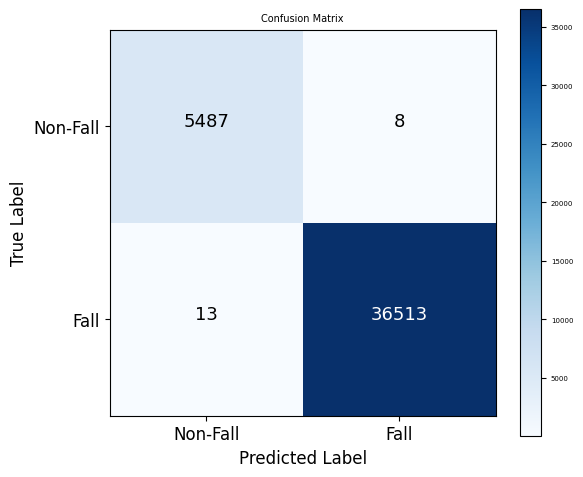

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix\n")
print(cm)

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Non-Fall", "Fall"]

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

threshold = cm.max()/2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,
                 i,
                 str(cm[i,j]),
                 ha="center",
                 color="white" if cm[i,j] > threshold else "black",
                 fontsize=13)

plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import classification_report

print("\n================ Classification Report ================\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Fall", "Fall"],
    digits=4
))


================ Classification Report ================

              precision    recall  f1-score   support

    Non-Fall     0.9976    0.9985    0.9981      5495
        Fall     0.9998    0.9996    0.9997     36526

    accuracy                         0.9995     42021
   macro avg     0.9987    0.9991    0.9989     42021
weighted avg     0.9995    0.9995    0.9995     42021



In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

print("\n================ Overall Performance ================\n")

print(f"Accuracy           : {accuracy_score(y_true,y_pred)*100:.2f}%")
print(f"Precision          : {precision_score(y_true,y_pred):.4f}")
print(f"Recall             : {recall_score(y_true,y_pred):.4f}")
print(f"F1-score           : {f1_score(y_true,y_pred):.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy_score(y_true,y_pred):.4f}")
print(f"MCC                : {matthews_corrcoef(y_true,y_pred):.4f}")
print(f"Cohen's Kappa      : {cohen_kappa_score(y_true,y_pred):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_true,y_score):.4f}")


================ Overall Performance ================

Accuracy           : 99.95%
Precision          : 0.9998
Recall             : 0.9996
F1-score           : 0.9997
Balanced Accuracy  : 0.9991
MCC                : 0.9978
Cohen's Kappa      : 0.9978
ROC-AUC            : 1.0000


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test_res)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test_res, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nRows = Actual, Cols = Predicted")
print("        Pred Non-Fall | Pred Fall")
print(f"Actual Non-Fall  {cm[0][0]:>8} | {cm[0][1]:>8}")
print(f"Actual Fall      {cm[1][0]:>8} | {cm[1][1]:>8}")

print("\n", classification_report(y_test_res, y_pred, target_names=['Non-Fall', 'Fall']))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  

plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',xticklabels=['Non-Fall', 'Fall'],yticklabels=['Non-Fall', 'Fall'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (%)')
plt.show()

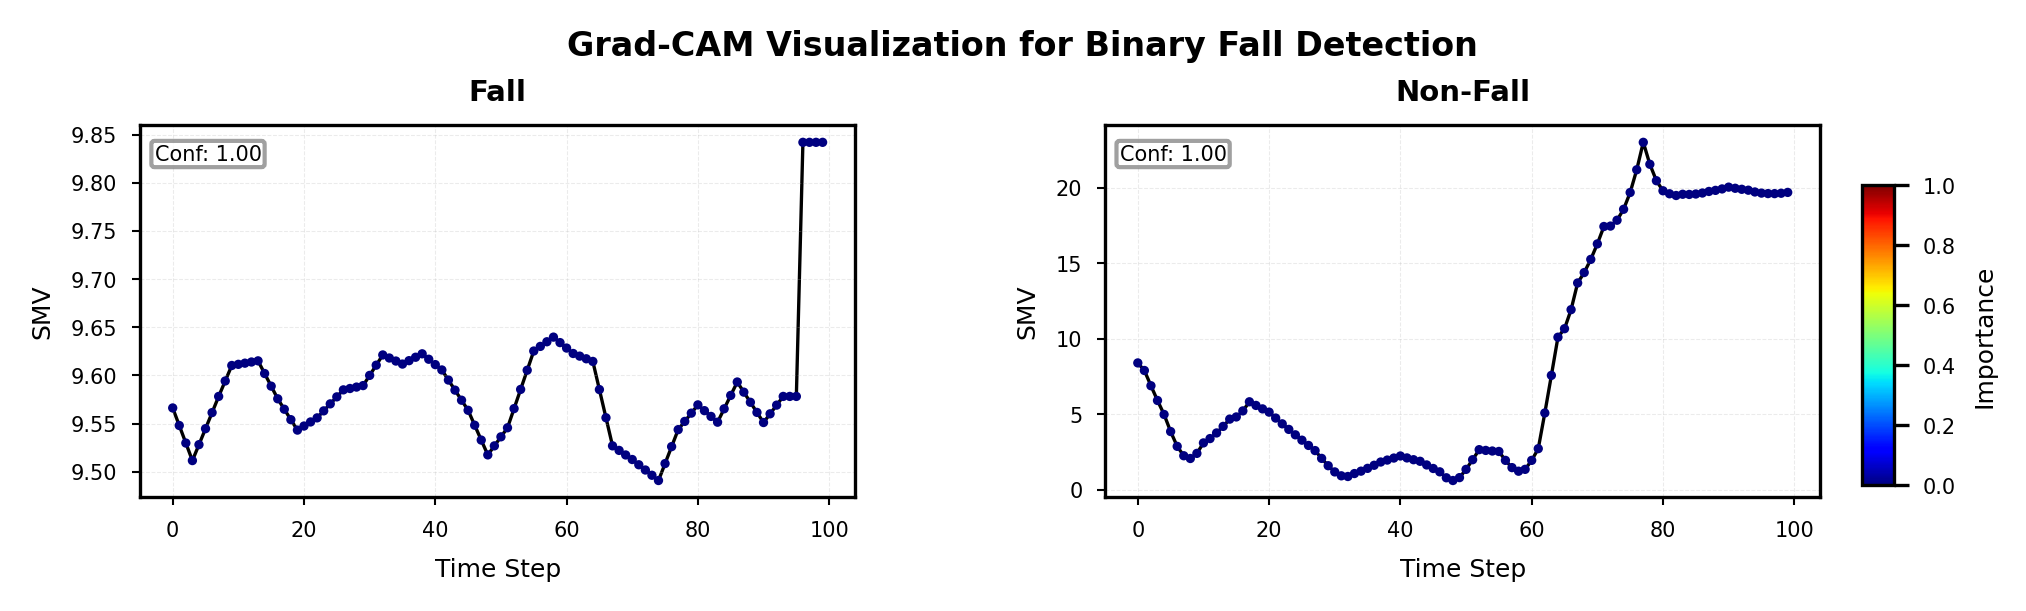

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# Grad-CAM Function
# ============================================================

def gradcam_1d(model, sample, layer_name="cnn7_gated"):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(sample)

        pred_class = tf.argmax(predictions[0])

        loss = predictions[:, pred_class]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(
        grads,
        axis=1
    )

    conv_outputs = conv_outputs[0]

    weights = weights[0]

    cam = tf.reduce_sum(
        conv_outputs * weights,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = gaussian_filter1d(
        cam,
        sigma=2
    )

    cam = cam / (cam.max() + 1e-8)

    confidence = np.max(predictions.numpy())

    return cam, int(pred_class.numpy()), confidence


# ============================================================
# Binary Class Names
# ============================================================

class_names = [
    "Fall",
    "Non-Fall"
]

# ============================================================
# IEEE Plot Settings
# ============================================================

plt.rcParams.update({

    "font.size":6,
    "axes.titlesize":7,
    "axes.labelsize":6,
    "xtick.labelsize":5,
    "ytick.labelsize":5,
    "legend.fontsize":5

})

# ============================================================
# Figure (1×2)
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(7,2),

    dpi=300,

    sharex=False,

    sharey=False

)

vmin = 0
vmax = 1

# ============================================================
# Loop over binary classes
# ============================================================

for cls in range(2):

    idxs = np.where(y_test_res == cls)[0]

    sample_idx = None

    # Find one correctly classified sample

    for idx in idxs:

        pred = np.argmax(

            model.predict(
                X_test_res[idx:idx+1],
                verbose=0
            )

        )

        if pred == cls:

            sample_idx = idx
            break

    if sample_idx is None:

        sample_idx = idxs[0]

    x = X_test_res[sample_idx:sample_idx+1]

    cam, pred, conf = gradcam_1d(

        model,
        x,
        layer_name="cnn7_gated"

    )

    # =====================================================
    # Signal Magnitude Vector (SMV)
    # =====================================================

    signal = np.sqrt(

        X_test_res[sample_idx,:,0]**2 +

        X_test_res[sample_idx,:,1]**2 +

        X_test_res[sample_idx,:,2]**2

    )

    ax = axes[cls]

    # =====================================================
    # Plot
    # =====================================================

    ax.plot(

        signal,

        color='black',

        linewidth=0.8,

        zorder=1

    )

    scatter = ax.scatter(

        np.arange(len(signal)),

        signal,

        c=cam,

        cmap='jet',

        s=5,

        edgecolors='none',

        vmin=vmin,

        vmax=vmax,

        zorder=2

    )

    # =====================================================

    ax.set_title(

        class_names[cls],

        fontsize=7,

        fontweight='bold'

    )

    ax.text(

        0.02,

        0.95,

        f"Conf: {conf:.2f}",

        transform=ax.transAxes,

        fontsize=5,

        va='top',

        bbox=dict(

            facecolor='white',

            edgecolor='gray',

            alpha=0.75,

            boxstyle='round,pad=0.15'

        )

    )

    ax.set_xlabel(

        "Time Step",

        fontsize=6

    )

    ax.set_ylabel(

        "SMV",

        fontsize=6

    )

    ax.tick_params(

        axis='both',

        labelsize=5,

        width=0.5,

        length=2

    )

    ax.grid(

        linestyle='--',

        linewidth=0.25,

        alpha=0.25

    )

# ============================================================
# Layout
# ============================================================

plt.subplots_adjust(

    left=0.08,

    right=0.88,

    bottom=0.20,

    top=0.82,

    wspace=0.35

)

# ============================================================
# Colorbar
# ============================================================

cax = fig.add_axes([0.90,0.22,0.015,0.50])

cbar = fig.colorbar(

    scatter,

    cax=cax

)

cbar.set_label(

    "Importance",

    fontsize=6

)

cbar.ax.tick_params(

    labelsize=5

)

# ============================================================
# Title
# ============================================================

fig.suptitle(

    "Grad-CAM Visualization for Binary Fall Detection",

    fontsize=8,

    fontweight='bold'

)

# ============================================================
# Save
# ============================================================

plt.savefig(

    "GradCAM_Binary_FallDetection.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()